In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_15112\1530099147.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


,id,old_order_id,increment_id,status,channel_name,is_guest,customer_email,customer_first_name,customer_last_name,shipping_method,...,additional,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
0,1,NaN,ORD-00000001,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,ORD-00000002,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,ORD-00000003,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,ORD-00000004,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,ORD-00000005,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_clean = df.copy()
df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)
df_clean = df_clean.dropna(subset=['target'])





### ==========================================
### FEATURE ENGINEERING 
### ==========================================

In [4]:

df_clean['discount_ratio'] = df_clean['discount_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['tax_ratio'] = df_clean['tax_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['shipping_ratio'] = df_clean['shipping_amount'] / (df_clean['grand_total'] + 1e-5)

df_clean['avg_item_price'] = df_clean['sub_total'] / (df_clean['total_qty_ordered'] + 1e-5)

df_clean['net_basket_value'] = df_clean['sub_total'] - df_clean['discount_amount']

### ==========================================
### FEATURE SELECTION 
### ==========================================


In [5]:

useless_cols = [
    'cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 
    'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 
    'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 'shipping_title', 
    'shipping_description', 'coupon_code', 'created_at', 'updated_at', 'additional', 'status'
]
df_clean = df_clean.drop(columns=[col for col in useless_cols if col in df_clean.columns])

# Features aur Target alag karna
X_raw = df_clean.drop(columns=['target'])
y = df_clean['target']



### ==========================================
### MISSING VALUES & ENCODING
### ==========================================


In [6]:

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns

high_card_cols = [col for col in cat_cols if X_raw[col].nunique() > 50]
if high_card_cols:
    X_raw = X_raw.drop(columns=high_card_cols)
    cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns

X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"Engineered Data Shape: {X.shape}")



Engineered Data Shape: (146201, 75)


### ==========================================
### TRAIN-TEST SPLIT (Stratified)
### ==========================================

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### ==========================================
### INITIALIZING ADABOOST MODEL
### ==========================================

In [14]:

ada_model = AdaBoostClassifier(
    n_estimators=500,      
    learning_rate=0.1,     
    random_state=42
)



### ==========================================
### TRAINING THE MODEL
### ==========================================

In [15]:

print("Training AdaBoost Ensemble (Sequential Learning started)...")
ada_model.fit(X_train, y_train)
print("Training Complete!")



Training AdaBoost Ensemble (Sequential Learning started)...
Training Complete!


### ==========================================
### PREDICTIONS & EVALUATION
### ==========================================

In [16]:

y_pred_ada = ada_model.predict(X_test)

print("\n" + "=" * 50)
print(" ADABOOST MODEL PERFORMANCE ")
print("=" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ada):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
print("=" * 50)




 ADABOOST MODEL PERFORMANCE 
Accuracy Score: 0.9547

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93      9245
           1       0.98      0.95      0.97     19996

    accuracy                           0.95     29241
   macro avg       0.94      0.95      0.95     29241
weighted avg       0.96      0.95      0.95     29241



### ==========================================
### CONFUSION MATRIX VISUALIZATION
### ==========================================

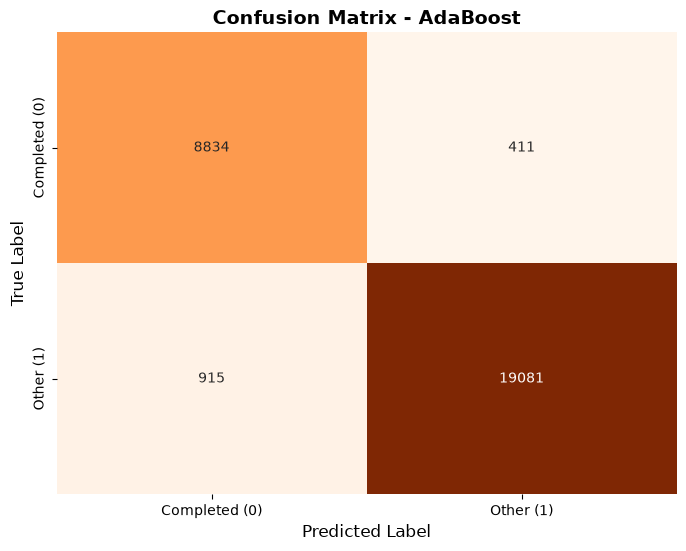

In [17]:

cm_ada = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Completed (0)', 'Other (1)'],
            yticklabels=['Completed (0)', 'Other (1)'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - AdaBoost', fontsize=14, fontweight='bold')
plt.show()